# Mice V1 Tutorial Companion

This notebook walks through the tutorial pipeline cell by cell.
Each section calls one exported function from `run_tutorial_generate_and_sim_notebook.py`,
so we can inspect intermediate objects before moving on to the next stage.

## 1. Imports

We import the notebook-native step functions so each tutorial stage can be run independently.

In [17]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from omegaconf import OmegaConf

from run_tutorial_generate_and_sim_notebook import (
    initialize_tutorial_context,
    tutorial_step_1_configure_network,
    tutorial_step_2_generate_neurons,
    tutorial_step_3_generate_connections,
    tutorial_step_4_write_glif_templates,
    tutorial_step_5_bridge_assets,
    tutorial_step_6_build_model,
    tutorial_step_7_generate_input,
    tutorial_step_8_run_simulation,
)


## 2. Load Config And Initialize Context

This prepares the output folders, logger, random seed, and runtime config.
Feel free to change `cfg.out_dir` if you want a different output location.

In [18]:
cfg = OmegaConf.load("tutorial_generate_and_sim.yaml")
cfg.device = "cpu"
cfg.out_dir = "./notebook_outputs"
cfg.show_inline_figures = True

context = initialize_tutorial_context(cfg)
context["output_dir"]


Logging initialized. Log file: notebook_outputs/training.log


Tutorial Configuration:
seed: 42
device: cpu
dtype: float32
out_dir: ./notebook_outputs
visualize: true
figures_to_plot:
- voltage
- post_synapse_current
- spike
- fr_spectrum
max_neurons_raster: null
simulation:
  name: sim
  T: 300
  dt: 1.0
  n_neuron: null
  batch_size: 8
  psc_time_range_ms:
  - 0
  - null
dataset:
  type: noisydc_ou
  current_mode: rheobase_scaled
  scale_factor: 1.05
  std: 0.25
  tau_ou: 20.0
  scale_noise_with_mean: true
input:
  type: all
network:
  name: tutorial_network
  conn_path: null
  glif_dir: null
  synapse_impl: hetersyn
  n_neuron: null
  weight:
    type: from_conn
    weight_ee_scale: 1.0
    weight_ei_scale: 1.0
    weight_ie_scale: 1.0
    weight_ii_scale: 1.0
  synapse:
    type: alpha
    tau_syn_ee: 2.25
    tau_syn_ie: 5.5
    tau_syn_ei: 2.8
    tau_syn_ii: 5.8
  input_layer:
    type: identical
    value: 1.0
tutorial:
  network:
    n_exc: 80
    n_inh: 20
    spatial_span_um: 200.0
    connection_probabilities:
      EE: 0.35
      EI: 

PosixPath('notebook_outputs')

## 3. Inspect The Network Configuration

Before generating anything, we inspect the tiny E/I network that will be built.

In [19]:
step1 = tutorial_step_1_configure_network(context)
pd.DataFrame([step1["summary"]])


============== Tutorial Step 1: Configure The Mock Network ==============
Network summary | n_exc=80 n_inh=20 spatial_span_um=200.0
Connection probabilities: {'EE': 0.35, 'EI': 0.45, 'IE': 0.7, 'II': 0.4}
Weight ranges: {'EE': [0.6, 1.0], 'EI': [0.8, 1.2], 'IE': [0.9, 1.3], 'II': [0.7, 1.1]}


,seed,n_exc,n_inh,spatial_span_um,connection_probabilities,weight_ranges
0,42,80,20,200.0,"{'EE': 0.35, 'EI': 0.45, 'IE': 0.7, 'II': 0.4}","{'EE': [0.6, 1.0], 'EI': [0.8, 1.2], 'IE': [0...."


## 4. Generate The Neuron Table

Each row describes one neuron in the mock recurrent network.

In [20]:
step2 = tutorial_step_2_generate_neurons(context)
display(step2["neurons"].head())
step2["neuron_counts_by_ei"]


============== Tutorial Step 2: Generate The Neuron Table ==============
Neuron table head:
 root_id  simple_id       type layer   cell_class EI  x_position  y_position  z_position
    1000          0 Excitatory    L4 tutorial_pyr  E  154.791214   87.775688  171.719589
    1001          1 Excitatory    L4 tutorial_pyr  E  139.473602   18.835470  195.124466
    1002          2 Excitatory    L4 tutorial_pyr  E  152.227936  157.212860   25.622726
    1003          3 Excitatory    L4 tutorial_pyr  E   90.077187   74.159607  185.352997
    1004          4 Excitatory    L4 tutorial_pyr  E  128.773026  164.552322   88.682838
Neuron counts by EI type:
EI
E    80
I    20


,root_id,simple_id,type,layer,cell_class,EI,x_position,y_position,z_position
0,1000,0,Excitatory,L4,tutorial_pyr,E,154.791214,87.775688,171.719589
1,1001,1,Excitatory,L4,tutorial_pyr,E,139.473602,18.835470,195.124466
2,1002,2,Excitatory,L4,tutorial_pyr,E,152.227936,157.212860,25.622726
3,1003,3,Excitatory,L4,tutorial_pyr,E,90.077187,74.159607,185.352997
4,1004,4,Excitatory,L4,tutorial_pyr,E,128.773026,164.552322,88.682838


EI
E    80
I    20
Name: count, dtype: int64

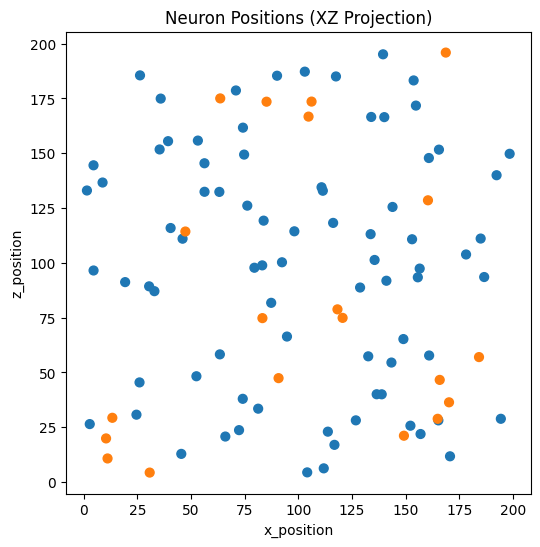

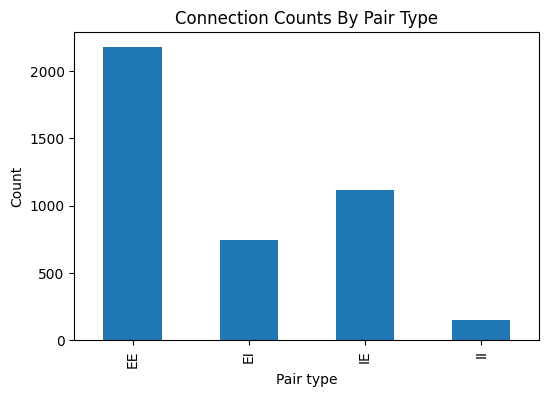

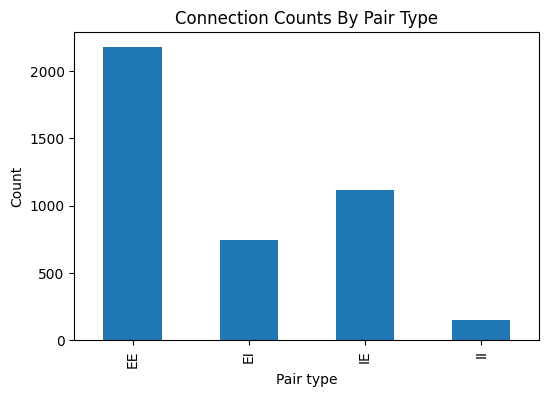

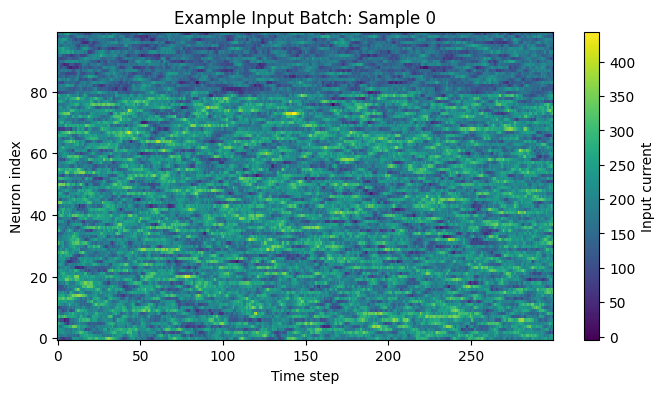

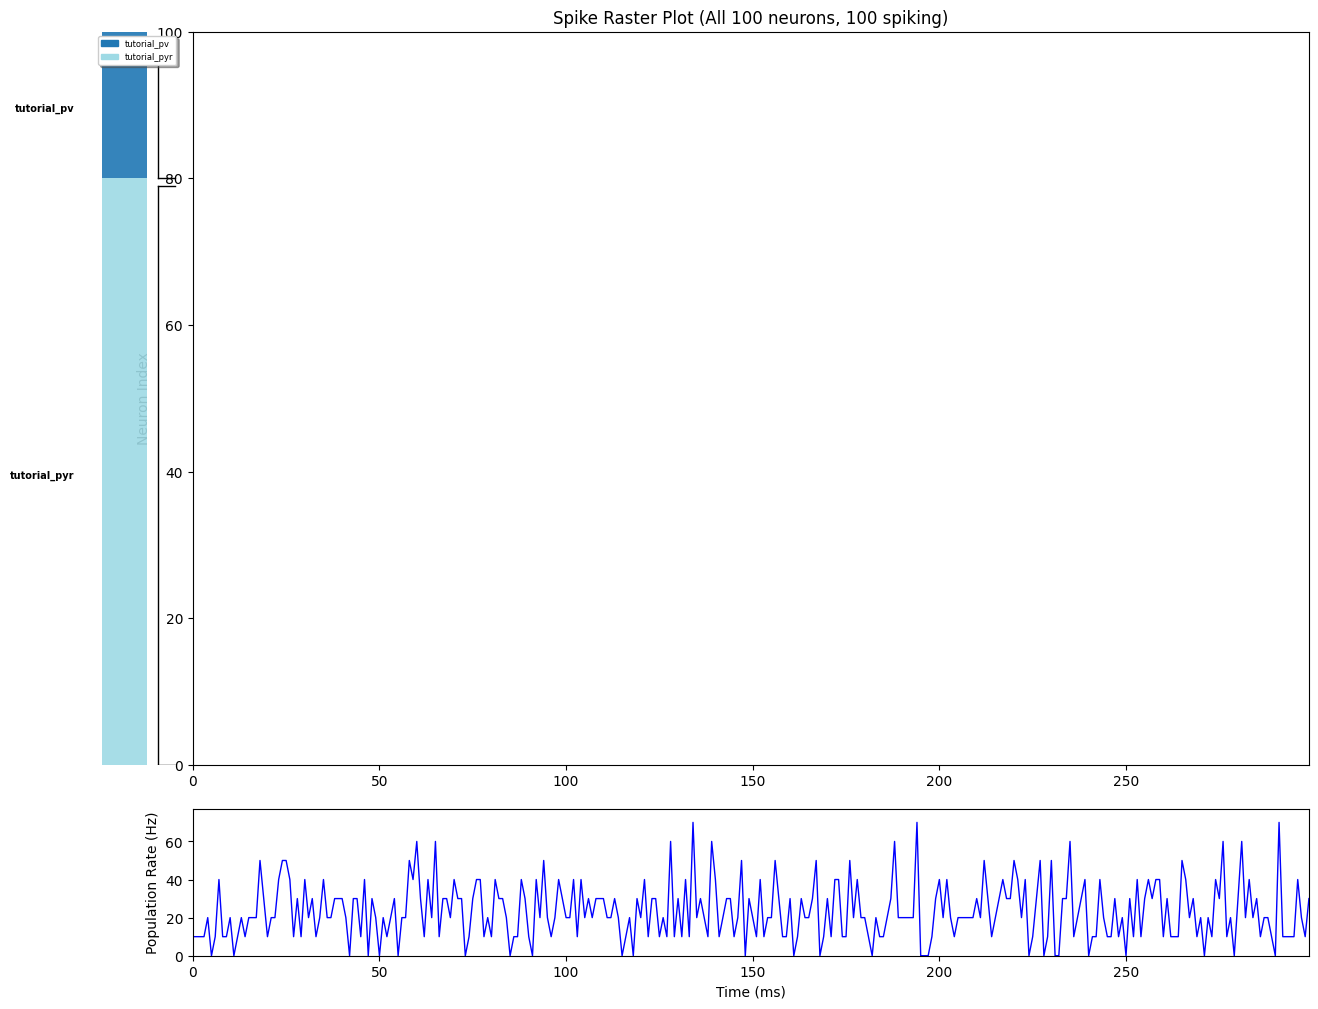

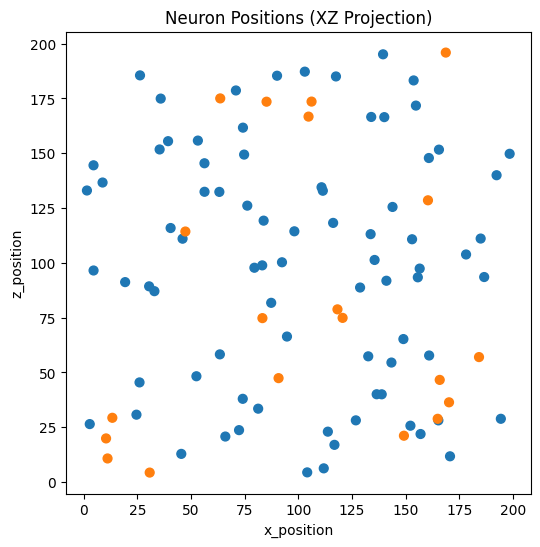

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = step2["neurons"]["EI"].map({"E": "tab:blue", "I": "tab:orange"})
ax.scatter(step2["neurons"]["x_position"], step2["neurons"]["z_position"], c=colors, s=40)
ax.set_xlabel("x_position")
ax.set_ylabel("z_position")
ax.set_title("Neuron Positions (XZ Projection)")
plt.show()


## 5. Generate The Connection Table

This is the explicit random network-building step.

In [22]:
step3 = tutorial_step_3_generate_connections(context, step2["neurons"])
display(step3["connections"].head())
step3["pair_counts"]


============== Tutorial Step 3: Generate The Connection Table ==============
Connection table head:
 pre_id  post_id  pre_simple_id  post_simple_id     pre_type    post_type EI  syn_count   weight
   1000     1002              0               2 tutorial_pyr tutorial_pyr  E          1 0.814427
   1000     1008              0               8 tutorial_pyr tutorial_pyr  E          1 0.655907
   1000     1011              0              11 tutorial_pyr tutorial_pyr  E          1 0.747005
   1000     1013              0              13 tutorial_pyr tutorial_pyr  E          1 0.751786
   1000     1015              0              15 tutorial_pyr tutorial_pyr  E          1 0.979543
Connection counts by pair type:
EE    2180
EI     748
IE    1116
II     151
Total generated connections: 4195


,pre_id,post_id,pre_simple_id,post_simple_id,pre_type,post_type,EI,syn_count,weight
0,1000,1002,0,2,tutorial_pyr,tutorial_pyr,E,1,0.814427
1,1000,1008,0,8,tutorial_pyr,tutorial_pyr,E,1,0.655907
2,1000,1011,0,11,tutorial_pyr,tutorial_pyr,E,1,0.747005
3,1000,1013,0,13,tutorial_pyr,tutorial_pyr,E,1,0.751786
4,1000,1015,0,15,tutorial_pyr,tutorial_pyr,E,1,0.979543


EE    2180
EI     748
IE    1116
II     151
Name: count, dtype: int64

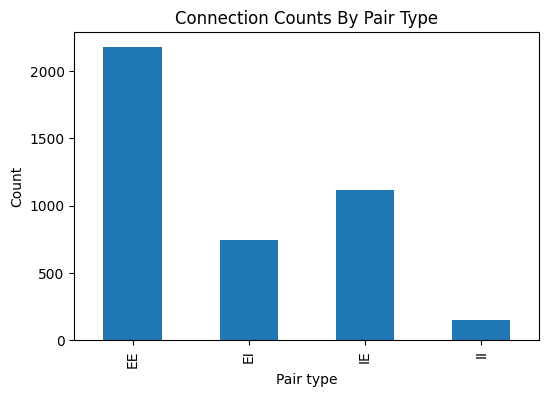

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
step3["pair_counts"].plot(kind="bar", ax=ax)
ax.set_title("Connection Counts By Pair Type")
ax.set_xlabel("Pair type")
ax.set_ylabel("Count")
plt.show()


## 6. Write Mock GLIF Templates And Bridge The Assets

At this stage, the generated CSVs and GLIF folders become the normal model inputs.

In [24]:
step4 = tutorial_step_4_write_glif_templates(context)
step5 = tutorial_step_5_bridge_assets(context, step2["neurons"], step3["connections"])

step4["class_names"], step5["metadata"]


============== Tutorial Step 4: Write Mock GLIF Templates ==============
GLIF template classes: ['tutorial_pyr', 'tutorial_pv']
============== Tutorial Step 5: Bridge Assets Into The Simulation Config ==============
Tutorial connectome path: notebook_outputs/tutorial_assets/connectome
Tutorial glif path: notebook_outputs/tutorial_assets/glif_models
Tutorial neuron count: 100


(['tutorial_pyr', 'tutorial_pv'],
 {'n_neurons': 100,
  'n_connections': 4195,
  'conn_path': 'notebook_outputs/tutorial_assets/connectome',
  'glif_dir': 'notebook_outputs/tutorial_assets/glif_models'})

## 7. Build The Spiking Model

Now we switch from the data-building phase to the actual btorch-backed simulation model.

In [25]:
step6 = tutorial_step_6_build_model(context)
step6["model"]


============== Tutorial Step 6: Build The Spiking Model ==============
Input selection | type=all n_input=100 n_total=100 E_in=80 I_in=20
⚖️  Using PRE-LOADED weights from connectome (Detailed)
Attached input-layer I_thr debug tensor: shape=(100,)
Model built on device: cpu
Loaded neuron parameter keys: ['El_reference', 'I_thr', 'c_m', 'max_Iasc', 'tau', 'tau_ref', 'use_glif_params', 'v_reset', 'v_rest', 'v_threshold', 'voltage_scale']


simple_ids[0]: 0
entering alpha synapse times
DEBUG: Signs injected into Alpha matrix (columns scaled).
synapse_args: {'n_neuron': 100, 'n_receptor': 4, 'receptor_type_index':    receptor_index pre_receptor_type post_receptor_type
0               0                 E                  E
1               1                 E                  I
2               2                 I                  E
3               3                 I                  I, 'linear': SparseConn(), 'base_psc': <class 'btorch.models.synapse.AlphaPSC'>, 'tau_syn': tensor([2.2500, 2.8000, 5.5000, 5.8000, 2.2500, 2.8000, 5.5000, 5.8000, 2.2500,
        2.8000, 5.5000, 5.8000, 2.2500, 2.8000, 5.5000, 5.8000, 2.2500, 2.8000,
        5.5000, 5.8000, 2.2500, 2.8000, 5.5000, 5.8000, 2.2500, 2.8000, 5.5000,
        5.8000, 2.2500, 2.8000, 5.5000, 5.8000, 2.2500, 2.8000, 5.5000, 5.8000,
        2.2500, 2.8000, 5.5000, 5.8000, 2.2500, 2.8000, 5.5000, 5.8000, 2.2500,
        2.8000, 5.5000, 5.8000, 2.2500, 2.8000, 5.5000, 5.8

BaseRSNN(
  (flybrain): FlyBrain(
    (brain): RecurrentNN(
      (neuron): GLIF3(
        c_m=shape=(100,), tau=shape=(100,), tau_ref=shape=(100,), n_Iasc=2, k=shape=(100, 2), asc_amps=shape=(100, 2), v_rest=shape=(100,), n_neuron=(100,), v_threshold=shape=(100,), v_reset=shape=(100,), step_mode=s, backend=torch, surrogate=ATan, hard_reset=True, memories=(v=(100,) init=shape=(100,), refractory=(100,) init=0, Iasc=(100, 2) init=shape=(2,))
        (surrogate_function): ATan()
      )
      (synapse): HeterSynapsePSC(
         step_mode=s, backend=torch
        (linear): SparseConn()
        (base_psc): AlphaPSC(
           step_mode=s, backend=torch
          (linear): SparseConn()
        )
      )
    )
    (input_layer): DCInputLayer()
  )
  (input_layer): DCInputLayer()
)

In [26]:
sorted(step6["neuron_params"].keys())


['El_reference',
 'I_thr',
 'c_m',
 'max_Iasc',
 'tau',
 'tau_ref',
 'use_glif_params',
 'v_reset',
 'v_rest',
 'v_threshold',
 'voltage_scale']

## 8. Generate And Preview The Input Batch

This is a good place to inspect the external drive before the recurrent simulation starts.

In [27]:
step7 = tutorial_step_7_generate_input(context, step6["model"])
step7["example_batch"].shape


============== Tutorial Step 7: Generate The Input Batch ==============


⚖️  Rheobase Scaling Enabled: Mean I_thr=190.00 pA, Factor=1.05
📦 Creating NoisyDC_OU Dataset (std=0.25)


Example input batch | shape=(8, 300, 100) mean=199.4845 std=57.1945 min=-59.4474 max=465.7570


torch.Size([8, 300, 100])

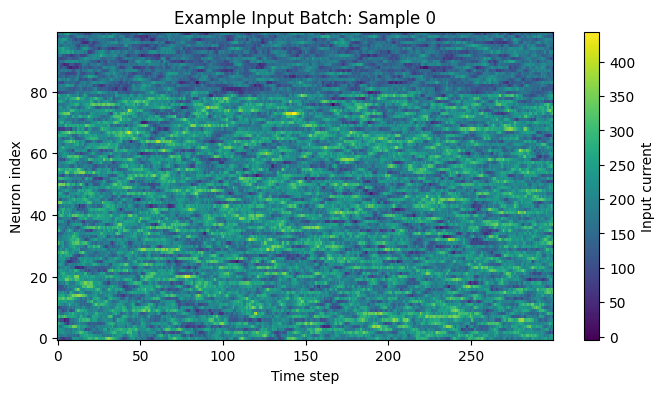

In [28]:
example = step7["example_batch"][0].cpu().numpy()  # [T, N]

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(example.T, aspect="auto", origin="lower", interpolation="nearest")
ax.set_xlabel("Time step")
ax.set_ylabel("Neuron index")
ax.set_title("Example Input Batch: Sample 0")
fig.colorbar(im, ax=ax, label="Input current")
plt.show()


## 9. Run The Simulation

This uses the shared `ExperimentRunner`, so the tutorial still follows the real simulation pipeline.

============== Tutorial Step 8: Run The Simulation ==============
🚀 Starting SIMULATION mode (No Gradient)
[InputDebug] input_indices=100 / total_neurons=100
[InputDebug] current_input stats: {'shape': (8, 300, 100), 'min': -25.537437438964844, 'max': 469.8916015625, 'mean': 199.90956115722656, 'std': 56.91704559326172}
[InputDebug] scaling_weights stats: {'shape': (100,), 'min': 0.05000000074505806, 'max': 0.0555555559694767, 'mean': 0.05111111328005791, 'std': 0.0022334172390401363}
[InputDebug] scaled_current stats: {'shape': (8, 300, 100), 'min': -1.276871919631958, 'max': 23.49458122253418, 'mean': 10.170626640319824, 'std': 2.770904779434204}
[InputDebug] voltage_scale_inputs stats: {'shape': (100,), 'min': 18.0, 'max': 20.0, 'mean': 19.600000381469727, 'std': 0.8040302395820618}
[InputDebug] I_thr(inputs) stats: {'shape': (100,), 'min': 150.0, 'max': 200.0, 'mean': 190.0, 'std': 20.10075569152832}
[InputDebug] inj_mean/I_thr stats: {'shape': (100,), 'min': 0.051161762326955795, 

device of inp: cpu


✅ Simulation complete.



🔍 按类别筛选神经元 (每类 4 个):
--------------------------------------------------
  - tutorial_pyr: 选中 4 个 (总数: 80)
  - tutorial_pv: 选中 4 个 (总数: 20)
--------------------------------------------------
✅ 总共选中 8 个代表性神经元


/home/liuxingyu/btorch-examples/mice_v1/src/utils/vis_utils.py:810: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
✅ Visualization complete.


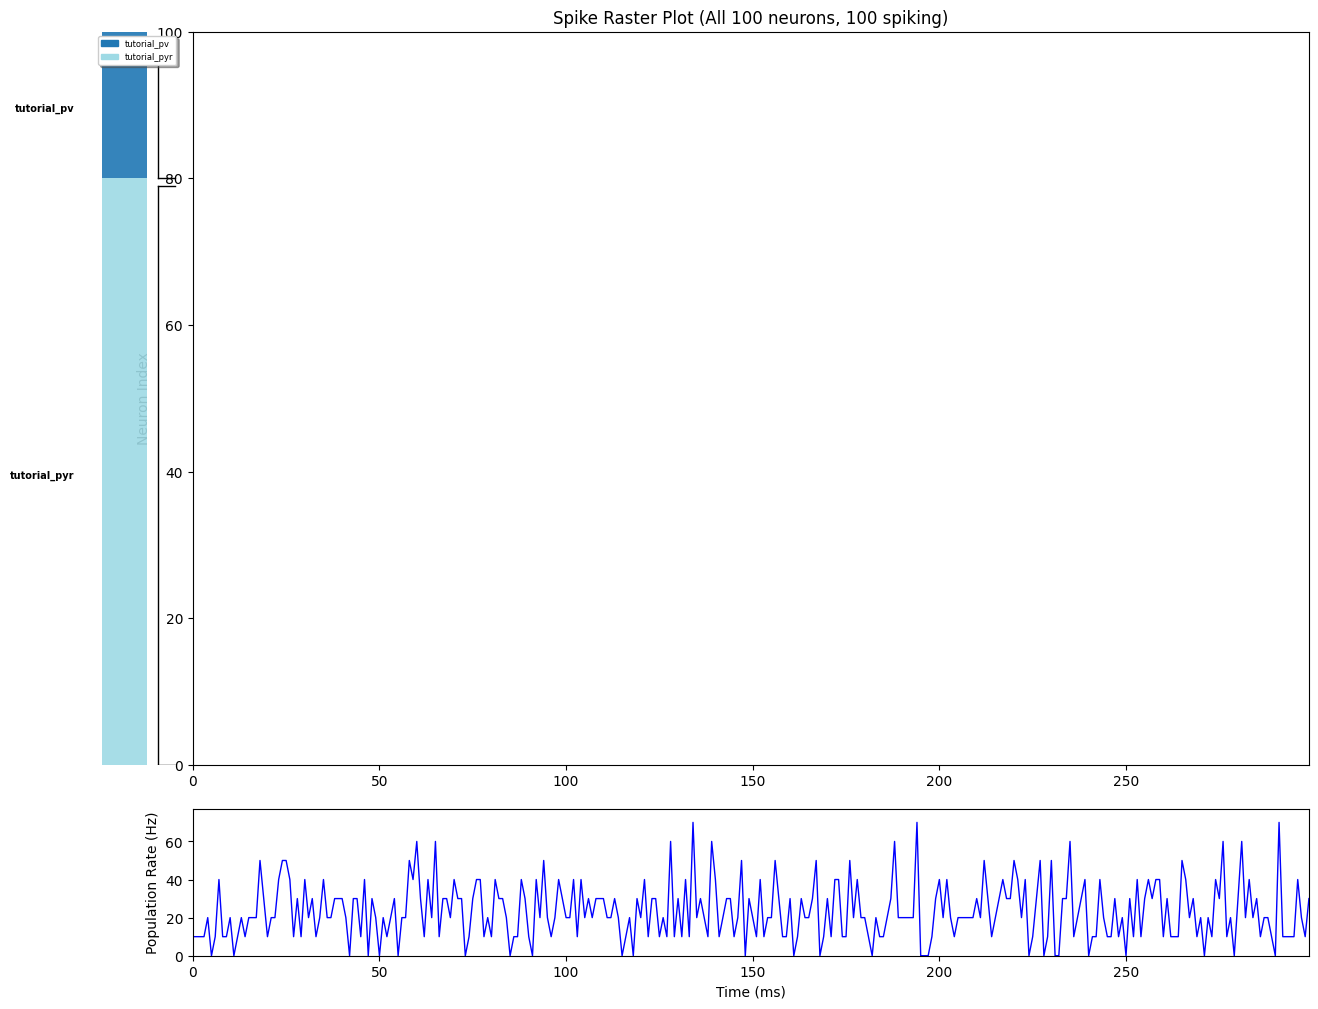

In [29]:
step8 = tutorial_step_8_run_simulation(context, step6["model"], step7["dataloaders"])
step8["runner"]


## 10. Inspect The Output Files

After the run, we can browse the generated tutorial assets, figures, metrics, and saved states.

In [30]:
output_dir = Path(context["output_dir"])
generated_files = sorted(str(path.relative_to(output_dir)) for path in output_dir.rglob("*") if path.is_file())
generated_files[:40]


['epoch_eval_None/mean_rate_spectrum.pdf',
 'epoch_eval_None/metrics.txt',
 'epoch_eval_None/population_psc_abs_sum.pdf',
 'epoch_eval_None/population_psc_signed_sum.pdf',
 'epoch_eval_None/post_synapse_E_current_responses.pdf',
 'epoch_eval_None/post_synapse_I_current_responses.pdf',
 'epoch_eval_None/post_synapse_I_current_responses_signed.pdf',
 'epoch_eval_None/post_synapse_current_combined.pdf',
 'epoch_eval_None/post_synapse_current_combined_signed.pdf',
 'epoch_eval_None/post_synapse_current_responses.pdf',
 'epoch_eval_None/spike_responses_full.jpg',
 'epoch_eval_None/voltage_responses.pdf',
 'epoch_eval_None/voltage_responses_single.pdf',
 'simulation_output/states_neuron/Iasc.parquet',
 'simulation_output/states_neuron/v.parquet',
 'simulation_output/states_spike/spike.parquet',
 'simulation_output/states_synapse/I_ext.parquet',
 'simulation_output/states_synapse/psc.parquet',
 'simulation_output/states_synapse/psc_all.parquet',
 'simulation_output/states_synapse/psc_e.parque